# Central moments, Skewness and Kurtosis

Central moments, skewness, and kurtosis are statistical measures used to describe the shape, center, and spread of a probability distribution or dataset. 

Central moments describe the characteristics of a dataset in relation to its arithmetic mean.

Skewness measures the lack of symmetry or the distortion of a bell curve. It shows whether data leans more to one side. 

Kurtosis (Peakedness) measures the peakedness or flatness of a distribution relative to a normal distribution (which has a standard bell shape). It describes the weight of the tails.

https://www.geeksforgeeks.org/data-science/difference-between-skewness-and-kurtosis/ 

## Central Moments


A **central moment** is just the average of a power of the deviation
$d_i = x_i - \bar{x}$. The power decides what the average is sensitive to.

| Moment | Formula | What it measures | Units |
|---|---|---|---|
| $m_1$ | $\frac{\sum d_i}{n}$ | nothing — it is always $0$ | $x$ |
| $m_2$ | $\frac{\sum d_i^2}{n}$ | spread (the population variance) | $x^2$ |
| $m_3$ | $\frac{\sum d_i^3}{n}$ | lopsidedness (which tail is longer) | $x^3$ |
| $m_4$ | $\frac{\sum d_i^4}{n}$ | tail weight (how much the extremes matter) | $x^4$ |

- **$m_1 = 0$ always.** Deviations above the mean exactly cancel the ones below —
  that is what "mean" means. So we need higher powers to learn anything.
- **$m_2$** squares the deviations, so signs disappear and everything adds up.
  It is never negative.
- **$m_3$** cubes them, so the **sign survives**: a negative deviation stays
  negative. If the few large deviations sit on the right, $m_3$ comes out
  positive; if they sit on the left it comes out negative. This is the only
  moment that tells us *which* side the tail is on.
- **$m_4$** uses the fourth power, so signs disappear again but extreme values are
  weighted enormously ($3^4 = 81$ against $1^4 = 1$). It is dominated by the tails.

The units are the problem: $m_3$ is in $x^3$, so its value changes if we switch
from metres to centimetres. Dividing by the right power of the standard deviation
removes the units, and *that* is what skewness and kurtosis are.


**Skewness** measures **asymmetry** — whether a distribution leans to one side.

> Skewness is the average cubed deviation from the mean, divided by the cubed
> standard deviation:
> $$g_1 = \frac{\frac{1}{n}\sum (x_i - \bar{x})^3}{\left[\frac{1}{n}\sum (x_i - \bar{x})^2\right]^{3/2}}$$

It is a single unitless number. Zero means symmetric; positive means the long
tail points right (a few unusually large values); negative means the long tail
points left. It answers *"which side is stretched out?"*

**Kurtosis** measures **tail weight** — how much of the spread comes from rare,
extreme values rather than from typical ones.

> Kurtosis is the average fourth-power deviation from the mean, divided by the
> squared variance:
> $$\frac{\frac{1}{n}\sum (x_i - \bar{x})^4}{\left[\frac{1}{n}\sum (x_i - \bar{x})^2\right]^{2}}$$

It is also unitless, and it is always positive. A normal distribution gives
exactly $3$, so subtracting $3$ gives **excess kurtosis**, on which a normal
distribution scores $0$. Positive excess kurtosis means heavier tails and more
outliers than a normal curve; negative means lighter tails and a flatter, more
even spread. It answers *"how much do the extremes matter?"*

Both are **shape** measures: unlike the mean and standard deviation, they do not
change if the data is shifted or rescaled. They describe the form of the
distribution, not its location or its size.

### What Skewness and Kurtosis Measure

Both are just moments made **unitless**, by dividing by the matching power of
$\sqrt{m_2}$ (the standard deviation).

**Skewness** $g_1 = \dfrac{m_3}{m_2^{3/2}}$ — asymmetry.

| Value | Shape |
|---|---|
| $g_1 = 0$ | symmetric (a normal curve) |
| $g_1 > 0$ | long tail to the **right**, mean pulled above the median |
| $g_1 < 0$ | long tail to the **left**, mean pulled below the median |

Benchmarks: a normal distribution has skewness $0$, an exponential always has
skewness exactly $2$.

**Kurtosis** $\dfrac{m_4}{m_2^2}$ — tail weight.

A normal distribution has this ratio equal to exactly $3$, which is why the
common version subtracts it:

$$g_2 = \frac{m_4}{m_2^2} - 3 \quad\text{(excess kurtosis)}$$

so that **a normal distribution scores 0**.

| Value | Shape |
|---|---|
| $g_2 = 0$ | tails like a normal curve |
| $g_2 > 0$ | heavier tails / more outliers (exponential is $+6$) |
| $g_2 < 0$ | lighter tails, flatter and more "boxy" |

Note that skewness and kurtosis are independent: a distribution can be skewed
and still have light tails, if it is spread fairly evenly across its range with
no extreme outliers.

###  Bias Correction

$m_2$, $m_3$ and $m_4$ all divide by $n$, which treats the data as if it were the
**entire population**. Usually it is not — it is a sample — and that creates a
systematic (not random) error:

> The deviations are measured from $\bar{x}$, the *sample* mean. The sample mean
> sits in the middle of *our own* points, closer to them than the true population
> mean would be. So every deviation comes out a little too small, and every moment
> built from them comes out a little too small too.

This is the exact same reason the sample variance divides by $n - 1$ instead of
$n$. Skewness and kurtosis need the same treatment, just with messier factors:

$$G_1 = \frac{n}{(n-1)(n-2)} \sum z_i^3
\qquad
G_2 = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum z_i^4 - \frac{3(n-1)^2}{(n-2)(n-3)}$$

where $z_i = \dfrac{x_i - \bar{x}}{s}$ and $s$ is the **sample** standard deviation
(the $n - 1$ one).

These factors are chosen so the result is right *on average* across repeated
samples. Two things to notice:

- The correction **moves the estimate away from zero**, because the uncorrected
  one was too small in magnitude.
- The factors all tend to $1$ as $n$ grows, so the correction only really matters
  for small samples. At $n = 30$ it shifts the answer by roughly 5%; at
  $n = 1000$ it would be invisible.

In SciPy this is the `bias` argument: `bias=True` is the raw moment version,
`bias=False` applies the correction above.

## 2. Comparison and Conditions: Exponential vs Normal

The mean, median and mode are enough to tell these two shapes apart.

| | Normal | Exponential |
|---|---|---|
| Shape | symmetric bell | starts high at 0, decays right |
| Mode | $\mu$ | $0$ (at the left edge) |
| Median | $\mu$ | $\dfrac{\ln 2}{\lambda} \approx 0.693\,\mu_{\text{exp}}$ |
| Mean | $\mu$ | $\dfrac{1}{\lambda}$ |
| Ordering | mode $=$ median $=$ mean | mode $<$ median $<$ mean |
| Std. dev. | free ($\sigma$) | equal to the mean |
| Skewness | $0$ | $2$ |
| Excess kurtosis | $0$ | $6$ |

**The one idea:** a long right tail drags the *mean* outward but barely moves the
*median*, and does not move the *mode* at all. So the gap between mean and median
is a direct read-out of right skew — which is the same information $m_3$ carries,
just measured differently.

**The conditions to check**, then, for a sample that might be exponential:

1. mean $>$ median (right skew at all)
2. mean $\approx 1.443 \times$ median
3. standard deviation $\approx$ mean
4. skewness $\approx 2$
5. excess kurtosis $\approx 6$

A normal sample instead needs mean $\approx$ median $\approx$ mode, skewness
$\approx 0$ and excess kurtosis $\approx 0$.

Lets plot a symmetrical Normal distribution and a right-skewed Exponential distribution, both configured with a mathematical mean of 4.

## Normal Distribution
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

## Exponential Distribution

$$f(x) = \frac{1}{\beta} e^{-\frac{x}{\beta}}$$

$$\text{Median} = \beta \ln(2) \approx 0.693 \times \beta$$



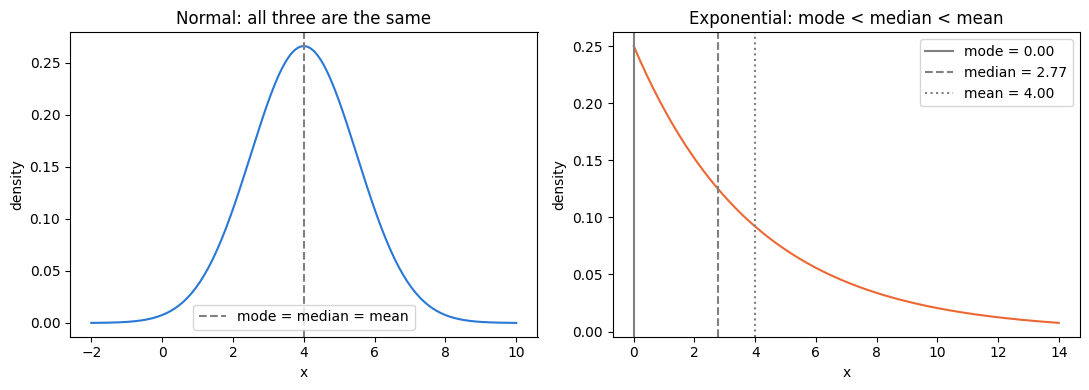

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Normal curve: mean = median = mode = 4
mu = 4
sigma = 1.5

# Generate an array of 200 evenly spaced numbers ranging from -2 to 10 using
xs = np.linspace(-2, 10, 200)

normal_pdf = np.exp(-0.5 * ((xs - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

# Exponential curve with mean 4: mode = 0, median = 0.693 * 4, mean = 4
scale = 4
xe = np.linspace(0, 14, 200)
expon_pdf = np.exp(-xe / scale) / scale

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(xs, normal_pdf, color='#2a78d6')
plt.axvline(mu, color='gray', linestyle='--', label='mode = median = mean')
plt.title('Normal: all three are the same')
plt.xlabel('x')
plt.ylabel('density')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(xe, expon_pdf, color='#eb6834')
plt.axvline(0, color='gray', linestyle='-', label='mode = 0.00')
plt.axvline(np.log(2) * scale, color='gray', linestyle='--', label='median = 2.77')
plt.axvline(scale, color='gray', linestyle=':', label='mean = 4.00')
plt.title('Exponential: mode < median < mean')
plt.xlabel('x')
plt.ylabel('density')
plt.legend()

plt.tight_layout()
plt.show()

## 3. The Numerical Question

Given the 30 observations below, find the mean, median and standard deviation,
the central moments, and the skewness and excess kurtosis (both the raw moment
version and the bias-corrected version). Then judge whether the data looks
normal or exponential.

In [2]:
x = [
    0.76, 1.53, 0.12, 2.44, 2.66, 3.84, 1.03, 6.31, 2.03, 4.61,
    9.53, 10.39, 3.69, 6.63, 6.4, 5.01, 2.99, 1.18, 0.35, 0.44,
    1.99, 7.04, 3.05, 7.89, 1.44, 1.11, 7.53, 10.4, 1.72, 4.96
]

n = len(x)
print('Number of observations:', n)

Number of observations: 30


## 4. Solution

### Option 1: Pure Python

#### Formulas

Mean:

$$\bar{x} = \frac{\sum x_i}{n}$$

Population central moments:

$$m_2 = \frac{\sum (x_i-\bar{x})^2}{n}$$

$$m_3 = \frac{\sum (x_i-\bar{x})^3}{n}$$

$$m_4 = \frac{\sum (x_i-\bar{x})^4}{n}$$

Moment skewness:

$$g_1 = \frac{m_3}{m_2^{3/2}}$$

Moment excess kurtosis:

$$g_2 = \frac{m_4}{m_2^2} - 3$$

In [3]:
import math

# Step 1: Mean, median, and standard deviation
total = sum(x)
mean = total / n
sorted_x = sorted(x)

if n % 2 == 0:
    median = (sorted_x[n // 2 - 1] + sorted_x[n // 2]) / 2
else:
    median = sorted_x[n // 2]

squared_deviations = [(value - mean) ** 2 for value in x]
population_variance = sum(squared_deviations) / n
population_sd = math.sqrt(population_variance)

sample_variance = sum(squared_deviations) / (n - 1)
sample_sd = math.sqrt(sample_variance)

print(f'Sum: {total:.5f}')
print(f'Mean: {mean:.5f}')
print(f'Median: {median:.5f}')
print(f'Population standard deviation: {population_sd:.5f}')
print(f'Sample standard deviation: {sample_sd:.5f}')

Sum: 119.07000
Mean: 3.96900
Median: 3.02000
Population standard deviation: 3.04536
Sample standard deviation: 3.09742


In [4]:
# Step 2: Central moments
deviations = [value - mean for value in x]

m1 = sum(deviations) / n
m2 = sum(d ** 2 for d in deviations) / n
m3 = sum(d ** 3 for d in deviations) / n
m4 = sum(d ** 4 for d in deviations) / n

print(f'm1 (first central moment):  {m1:.7f}')
print(f'm2 (second central moment): {m2:.7f}')
print(f'm3 (third central moment):  {m3:.7f}')
print(f'm4 (fourth central moment): {m4:.7f}')

m1 (first central moment):  0.0000000
m2 (second central moment): 9.2742157
m3 (third central moment):  18.9653307
m4 (fourth central moment): 198.8548312


In [5]:
# Step 3: Moment skewness and moment excess kurtosis
moment_skewness = m3 / (m2 ** 1.5)
moment_kurtosis = m4 / (m2 ** 2)
moment_excess_kurtosis = moment_kurtosis - 3

print(f'Moment skewness: {moment_skewness:.5f}')
print(f'Moment kurtosis (Pearson): {moment_kurtosis:.5f}')
print(f'Moment excess kurtosis: {moment_excess_kurtosis:.5f}')

Moment skewness: 0.67150
Moment kurtosis (Pearson): 2.31197
Moment excess kurtosis: -0.68803


### Option 2: Pandas + SciPy Stats

In SciPy:

- `bias=True` gives the moment coefficient.
- `bias=False` gives the bias-corrected sample statistic.
- `fisher=True` returns excess kurtosis, where normal kurtosis is 0.
- `fisher=False` returns Pearson kurtosis, where normal kurtosis is 3.

In [7]:
import pandas as pd
from scipy import stats

data = pd.Series(x, name='x')

print('Descriptive statistics:')
print(data.describe())
print()
print(f'Sum: {data.sum():.5f}')
print(f'Mean: {data.mean():.5f}')
print(f'Median: {data.median():.5f}')
print(f'Sample standard deviation: {data.std(ddof=1):.5f}')

Descriptive statistics:
count    30.000000
mean      3.969000
std       3.097421
min       0.120000
25%       1.462500
50%       3.020000
75%       6.377500
max      10.400000
Name: x, dtype: float64

Sum: 119.07000
Mean: 3.96900
Median: 3.02000
Sample standard deviation: 3.09742


In [8]:
# SciPy calculations
skew_moment = stats.skew(data, bias=True)
skew_adjusted = stats.skew(data, bias=False)

kurtosis_moment_excess = stats.kurtosis(data, fisher=True, bias=True)
kurtosis_adjusted_excess = stats.kurtosis(data, fisher=True, bias=False)

kurtosis_moment_pearson = stats.kurtosis(data, fisher=False, bias=True)
kurtosis_adjusted_pearson = stats.kurtosis(data, fisher=False, bias=False)

print(f'Moment skewness: {skew_moment:.5f}')
print(f'Adjusted sample skewness: {skew_adjusted:.5f}')
print()
print(f'Moment excess kurtosis: {kurtosis_moment_excess:.5f}')
print(f'Adjusted sample excess kurtosis: {kurtosis_adjusted_excess:.5f}')
print()
print(f'Moment Pearson kurtosis: {kurtosis_moment_pearson:.5f}')
print(f'Adjusted Pearson kurtosis: {kurtosis_adjusted_pearson:.5f}')

Moment skewness: 0.67150
Adjusted sample skewness: 0.70737

Moment excess kurtosis: -0.68803
Adjusted sample excess kurtosis: -0.58802

Moment Pearson kurtosis: 2.31197
Adjusted Pearson kurtosis: 2.41198


## 5. Checking the Conditions Against the Data

For our 30 values:

| Check | Value | Normal would give | Exponential would give |
|---|---|---|---|
| mean vs median | $3.97 > 3.02$ | equal | mean $\approx 1.44 \times$ median |
| sd / mean | $0.78$ | anything | $1.00$ |
| skewness | $0.67$ | $0$ | $2$ |
| excess kurtosis | $-0.69$ | $0$ | $6$ |

So the data is clearly right-skewed and **not** normal — but its skewness and
especially its kurtosis are far below the exponential's. The tails are too light.
It is a right-skewed distribution sitting somewhere between the two.

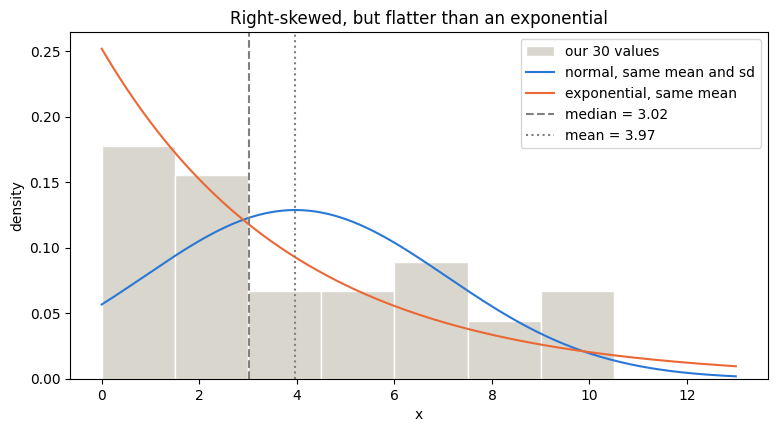

mean / median    = 1.314   (exponential: 1.443)
sample sd / mean = 0.780   (exponential: 1.000)
skewness         = 0.671   (normal: 0, exponential: 2)
excess kurtosis  = -0.688  (normal: 0, exponential: 6)


In [9]:
# Our 30 values compared with both shapes, each fitted to the same mean
grid = np.linspace(0, 13, 200)
normal_fit = np.exp(-0.5 * ((grid - mean) / sample_sd) ** 2) / (sample_sd * np.sqrt(2 * np.pi))
expon_fit = np.exp(-grid / mean) / mean

plt.figure(figsize=(9, 4.5))
plt.hist(x, bins=8, range=(0, 12), density=True,
         color='#d8d6cd', edgecolor='white', label='our 30 values')
plt.plot(grid, normal_fit, color='#2a78d6', label='normal, same mean and sd')
plt.plot(grid, expon_fit, color='#eb6834', label='exponential, same mean')
plt.axvline(median, color='gray', linestyle='--', label=f'median = {median:.2f}')
plt.axvline(mean, color='gray', linestyle=':', label=f'mean = {mean:.2f}')
plt.title('Right-skewed, but flatter than an exponential')
plt.xlabel('x')
plt.ylabel('density')
plt.legend()
plt.show()

print(f'mean / median    = {mean / median:.3f}   (exponential: 1.443)')
print(f'sample sd / mean = {sample_sd / mean:.3f}   (exponential: 1.000)')
print(f'skewness         = {moment_skewness:.3f}   (normal: 0, exponential: 2)')
print(f'excess kurtosis  = {moment_excess_kurtosis:.3f}  (normal: 0, exponential: 6)')

## 6. Conclusion

- $m_1 = 0$, as it must be; $m_2 = 9.27$ gives the spread, $m_3 = +18.97$ says the
  long tail is on the right, and $m_4 = 198.85$ carries the tail weight.
- The mean ($3.97$) is above the median ($3.02$), the usual signature of a right
  tail — and skewness is positive ($0.67$ raw, $0.71$ bias-corrected), which agrees.
- Excess kurtosis is negative ($-0.69$ raw, $-0.59$ corrected), so the tails are
  *lighter* than a normal curve's despite the skew.
- Bias correction pushes both statistics away from zero, because dividing by $n$
  had shrunk them. At $n = 30$ that is roughly a 5% shift.
- These numbers rule out a normal distribution, and they also rule out an
  exponential one: an exponential needs skewness $2$ and excess kurtosis $6$, and
  needs its standard deviation to equal its mean ($0.78$ here). A histogram,
  Q-Q plot, and a formal goodness-of-fit test are the next step.